# Imports

In [246]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import scipy.stats as ss

# Funções

In [247]:
def cramer_v( x, y ): 
    cm = pd.crosstab( x, y ).values
    n = cm.sum() 
    r, k = cm.shape 
    chi2 = ss.chi2_contingency( cm )[0] 
    chi2corr = max( 0, chi2 - (k-1)*(r-1)/(n-1) ) 
    kcorr = k - (k-1)**2/(n-1) 
    rcorr = r - (r-1)**2/(n-1) 

    return np.sqrt((chi2corr/n)/( min( kcorr-1, rcorr-1)))

# Loading Dataset

In [248]:
df = pd.read_excel('dataset/dataset_leite_realista.xlsx')

# Analisando os Dados

In [249]:
df.head().T

drop = ['index', 'Breed', 'Country', 'Climate_Zone', 'Management_System', 'Feed_Type', 'Feeding_Frequency', 'FMD_Vaccine', 'Brucellosis_Vaccine', 'Lot_ID', 'Milking_Interval_hrs', 'Grazing_Duration_hrs', 'Farm_ID', 'Housing_Score']

nome coluna: Health_Event_Day

mudança: Eu recomendaria Days_In_Health_Event: 0 para animais saudáveis e 1, 2, 3... durante o episódio. Isso fica mais intuitivo e evita usar -1.

In [250]:
#ajustando alguns dados e colunas
df1 = df.copy()

df1 = df1.rename(columns=({
    'Days_Since_Health_Event': 'Health_Event_Day'
}))

#df['sexo'] = df['sexo'].map({'M': 'Macho', 'F': 'Fêmea'})
#df['peso_kg'] = df['peso_lb'].map(lambda x: x * 0.453592)

df1['Health_Event_Day'] = df1['Health_Event_Day'].map(lambda x: x + 1)
df1['Heat_Stress_Level'] = df1['Heat_Stress_Level'].map(lambda x: 'Without' if pd.isna(x) else x)

df2 = df1.drop(drop, axis=1)
df2.head().T

,0,1,2,3,4
Cattle_ID,CATTLE_0001,CATTLE_0002,CATTLE_0003,CATTLE_0004,CATTLE_0005
Age_Months,58.6,80.7,50.8,88.6,57.2
Weight_kg,648.7,633.7,644.5,567.7,653.4
Parity,3,5,3,5,3
Lactation_Stage,Early,Early,Early,Early,Mid
Days_in_Milk,50,55,20,81,137
Feed_Quantity_kg,25.85,22.88,22.72,20.29,22.39
Water_Intake_L,69.0,72.8,64.6,56.2,72.7
Walking_Distance_km,1.39,0.59,0.54,0.8,0.41
Rumination_Time_hrs,8.56,7.99,7.64,7.79,7.75


In [251]:
#criando novas features

df2.dtypes
df2['Desvio'] = df2['Milk_Yield_L'] - df2['Previous_Week_Avg_Yield']

df2['Milk_Mean_15_Days_Ago'] = (
    df2.groupby('Cattle_ID')['Milk_Yield_L']
      .transform(lambda x: x.shift(1).rolling(15).mean())
)

df2['Milk_Yield_L_15_Days_from_now'] = df2.groupby('Cattle_ID')['Milk_Yield_L'].shift(-15)

df2 = df2.dropna(subset=['Milk_Mean_15_Days_Ago'])
df2 = df2.dropna(subset=['Milk_Yield_L_15_Days_from_now'])

In [252]:
df2.loc[df2['Cattle_ID'] == 'CATTLE_0001', :].tail(20).T

,10260,10440,10620,10800,10980,11160,11340,11520,11700,11880,12060,12240,12420,12600,12780,12960,13140,13320,13500,13680
Cattle_ID,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001
Age_Months,60.5,60.5,60.6,60.6,60.6,60.7,60.7,60.7,60.8,60.8,60.8,60.9,60.9,60.9,61.0,61.0,61.0,61.1,61.1,61.1
Weight_kg,643.6,651.2,637.2,640.1,644.5,649.6,647.8,643.8,646.7,644.1,646.4,643.1,645.4,640.7,646.2,640.1,651.7,649.1,647.5,650.9
Parity,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
Lactation_Stage,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid
Days_in_Milk,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126
Feed_Quantity_kg,25.47,25.67,24.76,25.25,24.92,25.59,24.4,25.67,24.89,24.97,25.56,25.77,24.44,24.55,23.83,25.64,26.19,25.06,24.06,23.82
Water_Intake_L,73.8,78.8,82.4,75.5,74.6,85.2,86.8,78.3,75.1,74.8,68.3,83.1,81.7,77.2,68.7,73.8,80.5,62.9,78.8,73.6
Walking_Distance_km,1.12,0.82,0.86,0.76,0.1,1.41,1.36,0.34,0.68,1.1,0.8,1.03,0.26,0.67,0.72,1.13,0.93,0.4,0.67,1.24
Rumination_Time_hrs,7.3,7.96,7.93,7.87,7.77,8.11,7.41,7.75,8.68,8.02,7.58,7.71,8.21,8.17,7.35,7.65,8.36,7.6,7.86,7.8


In [253]:
#conferindo celulas vazias e duplicadas
df2.isna().sum()
print(df2.shape)
df2.duplicated().sum()


(11160, 27)


np.int64(0)

# Análise Descritiva

### Variáveis Númericas

In [254]:
num_atributos = df2.select_dtypes(include=['float64', 'int'])
num_atributos.T

,2700,2701,2702,2703,2704,2705,2706,2707,2708,2709,...,13850,13851,13852,13853,13854,13855,13856,13857,13858,13859
Age_Months,59.100000,81.200000,51.300000,89.100,57.700000,31.400000,45.700,73.100000,57.70,34.200,...,58.200000,44.700000,36.600,57.000,63.700000,33.200000,48.400000,101.200000,46.100,35.200
Weight_kg,646.200000,634.700000,631.100000,565.100,671.600000,588.400000,582.600,668.400000,644.00,592.700,...,603.200000,632.500000,658.900,542.500,738.900000,597.000000,612.200000,657.500000,669.000,651.000
Parity,3.000000,5.000000,3.000000,5.000,3.000000,1.000000,2.000,4.000000,3.00,1.000,...,3.000000,2.000000,1.000,3.000,3.000000,1.000000,2.000000,6.000000,2.000,1.000
Days_in_Milk,65.000000,70.000000,35.000000,96.000,152.000000,50.000000,101.000,123.000000,107.00,215.000,...,145.000000,117.000000,257.000,190.000,215.000000,180.000000,265.000000,271.000000,258.000,193.000
Feed_Quantity_kg,24.460000,23.660000,21.790000,20.320,21.970000,19.140000,23.810,22.810000,22.74,18.460,...,21.040000,22.700000,18.430,17.350,21.270000,19.430000,21.850000,19.840000,22.800,21.540
Water_Intake_L,86.500000,69.600000,75.000000,69.800,59.500000,63.300000,71.300,72.500000,78.50,57.600,...,64.100000,67.800000,44.100,61.900,59.300000,66.800000,62.800000,62.500000,84.700,72.200
Walking_Distance_km,0.690000,0.440000,1.250000,0.760,0.900000,1.240000,0.890,1.470000,0.61,1.330,...,1.220000,1.350000,0.260,1.310,1.100000,1.250000,0.620000,0.640000,0.550,1.060
Rumination_Time_hrs,7.990000,7.100000,7.380000,7.680,7.280000,8.010000,7.840,7.550000,8.09,7.920,...,8.330000,7.150000,7.460,8.020,7.550000,7.870000,6.830000,7.290000,7.830,7.960
Resting_Hours,10.330000,11.710000,11.690000,11.860,9.910000,10.310000,10.860,10.880000,10.98,11.170,...,13.320000,12.030000,11.160,10.730,12.280000,12.060000,11.550000,10.580000,12.060,11.450
Ambient_Temperature_C,24.000000,24.000000,24.000000,24.000,24.000000,24.000000,24.000,24.000000,24.00,24.000,...,22.600000,22.600000,22.600,22.600,22.600000,22.600000,22.600000,22.600000,22.600,22.600


In [255]:
#tendencia central - média e mediana

ct1 = pd.DataFrame(num_atributos.mean()).T

ct2 = pd.DataFrame(num_atributos.median()).T

#dispersão: std, minimo, maximo, range, skewness, kurtosis

d1 = pd.DataFrame(num_atributos.std()).T
d2 = pd.DataFrame(num_atributos.min()).T
d3 = pd.DataFrame(num_atributos.max()).T
d4 = pd.DataFrame(num_atributos.max() - num_atributos.min()).T
d5 = pd.DataFrame(num_atributos.skew()).T
d6 = pd.DataFrame(num_atributos.kurtosis()).T

#concatenar os resultados
m = pd.concat([ct1, ct2, d1, d2, d3, d4, d5, d6], axis=0).T.reset_index()

#trocando nome das colunas
m.columns = ['atributos', 'mean', 'median', 'std', 'min', 'max', 'range', 'skew', 'kurtosis']
m

#skew:
#-0.5 a 0.5: pouco assimetria
#-1 a -0,5: assimetrica moderadamente
#0.5 a 1: assimetrica moderadamente
#-1 < e > 1: assimetria forte

,atributos,mean,median,std,min,max,range,skew,kurtosis
0,Age_Months,58.413513,57.500000,21.405634,26.600,107.500000,80.900000,0.416753,-0.872222
1,Weight_kg,628.119292,628.350000,46.135323,514.100,779.400000,265.300000,0.305482,0.146604
2,Parity,2.950000,3.000000,1.582176,1.000,6.000000,5.000000,0.410546,-0.926050
3,Days_in_Milk,155.344444,155.000000,60.986366,30.000,289.000000,259.000000,0.058392,-1.083035
4,Feed_Quantity_kg,21.428289,21.450000,2.010232,14.980,27.640000,12.660000,-0.011894,-0.282332
5,Water_Intake_L,66.200081,66.100000,8.737388,36.600,97.200000,60.600000,0.004400,-0.082027
6,Walking_Distance_km,0.847427,0.850000,0.318150,0.100,2.080000,1.980000,0.043860,-0.176442
7,Rumination_Time_hrs,7.648142,7.650000,0.444988,5.880,9.200000,3.320000,-0.063769,0.063475
8,Resting_Hours,11.183751,11.190000,0.849446,7.900,13.500000,5.600000,-0.053833,-0.061687
9,Ambient_Temperature_C,23.559677,23.450000,1.595980,19.800,27.400000,7.600000,0.114253,-0.415406


### Variáveis Categóricas

In [256]:
cat_atributos = df2.select_dtypes(exclude=['float64', 'int', 'datetime64'])
cat_atributos.T
print(cat_atributos.columns)

Index(['Cattle_ID', 'Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status'],
      dtype='str')


In [257]:
ct3 = cat_atributos.nunique()
ct3

Cattle_ID               180
Lactation_Stage           3
Heat_Stress_Level         3
Season                    2
Body_Condition_Class      3
Health_Status             4
dtype: int64

# Hipóteses

1. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio
2. Vacas com idade mediana produz mais leite que as demais faixas de idade
3. Vacas mais pesadas tendem a produzir mais leite
4. Vacas com número de partos mediano produz mais leite que as demais faixas de numero de partos
5. Vacas que ingerem mais águas produzem mais litros leite diários
6. Vacas que andam mais, produzem menos litros de leite diários
7. Vacas que descansam mais tem mais produtividade litros de leite diários
8. Vacas no outono produzem mais litros de leite diariamente
9. Na maior parte das vezes, vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite
10. Vacas com score corporal 3 tendem a ter maior produtividade diária
11. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária
12. Vacas saudáveis tendem a produzir mais litros de leite 

# E.D.A

### Análise Univariada

#### Variável Resposta

<Axes: xlabel='Milk_Yield_L', ylabel='Count'>

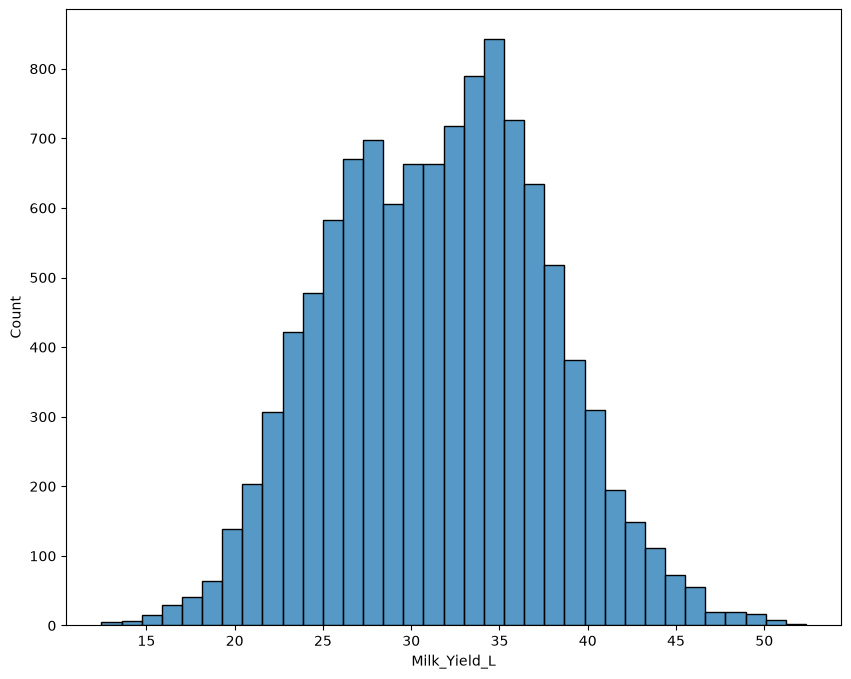

In [258]:
#estudo da variável resposta espsota que é variável contínua

plt.figure(figsize=(10,8))

#gráfico que plota a variável respsota
sns.histplot(df2['Milk_Yield_L'], bins=35)

#### Variáveis Numéricas

array([[<Axes: title={'center': 'Age_Months'}>,
        <Axes: title={'center': 'Weight_kg'}>,
        <Axes: title={'center': 'Parity'}>,
        <Axes: title={'center': 'Days_in_Milk'}>],
       [<Axes: title={'center': 'Feed_Quantity_kg'}>,
        <Axes: title={'center': 'Water_Intake_L'}>,
        <Axes: title={'center': 'Walking_Distance_km'}>,
        <Axes: title={'center': 'Rumination_Time_hrs'}>],
       [<Axes: title={'center': 'Resting_Hours'}>,
        <Axes: title={'center': 'Ambient_Temperature_C'}>,
        <Axes: title={'center': 'Humidity_percent'}>,
        <Axes: title={'center': 'Temperature_Humidity_Index'}>],
       [<Axes: title={'center': 'Previous_Week_Avg_Yield'}>,
        <Axes: title={'center': 'Body_Condition_Score'}>,
        <Axes: title={'center': 'Milking_Frequency_per_day'}>,
        <Axes: title={'center': 'Health_Event_Day'}>],
       [<Axes: title={'center': 'Milk_Yield_L'}>,
        <Axes: title={'center': 'Desvio'}>,
        <Axes: title={'center

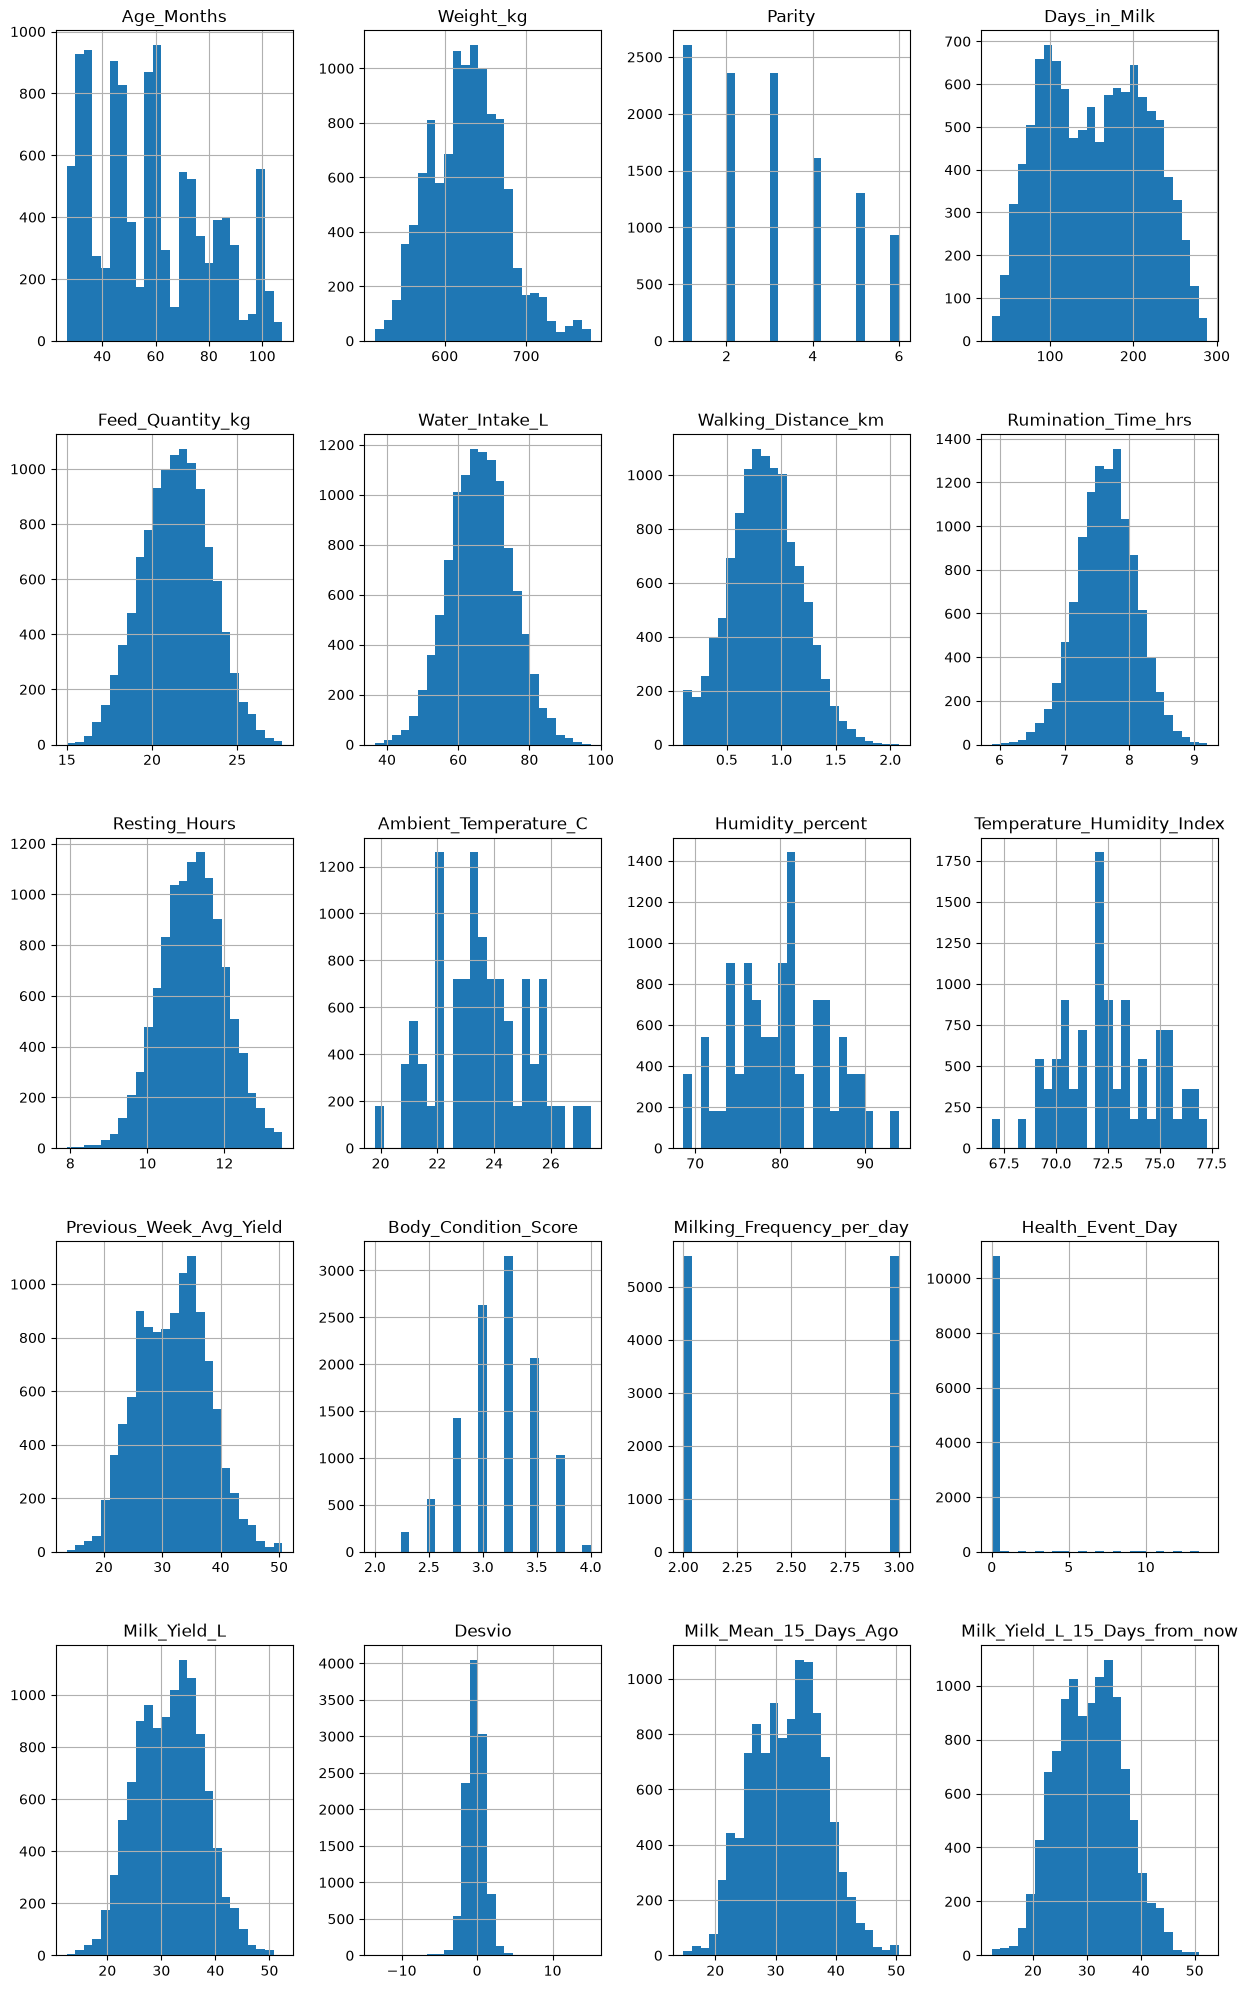

In [259]:
num_atributos.hist(bins = 25, figsize=(15,25))

#### Variáveis Categóricas

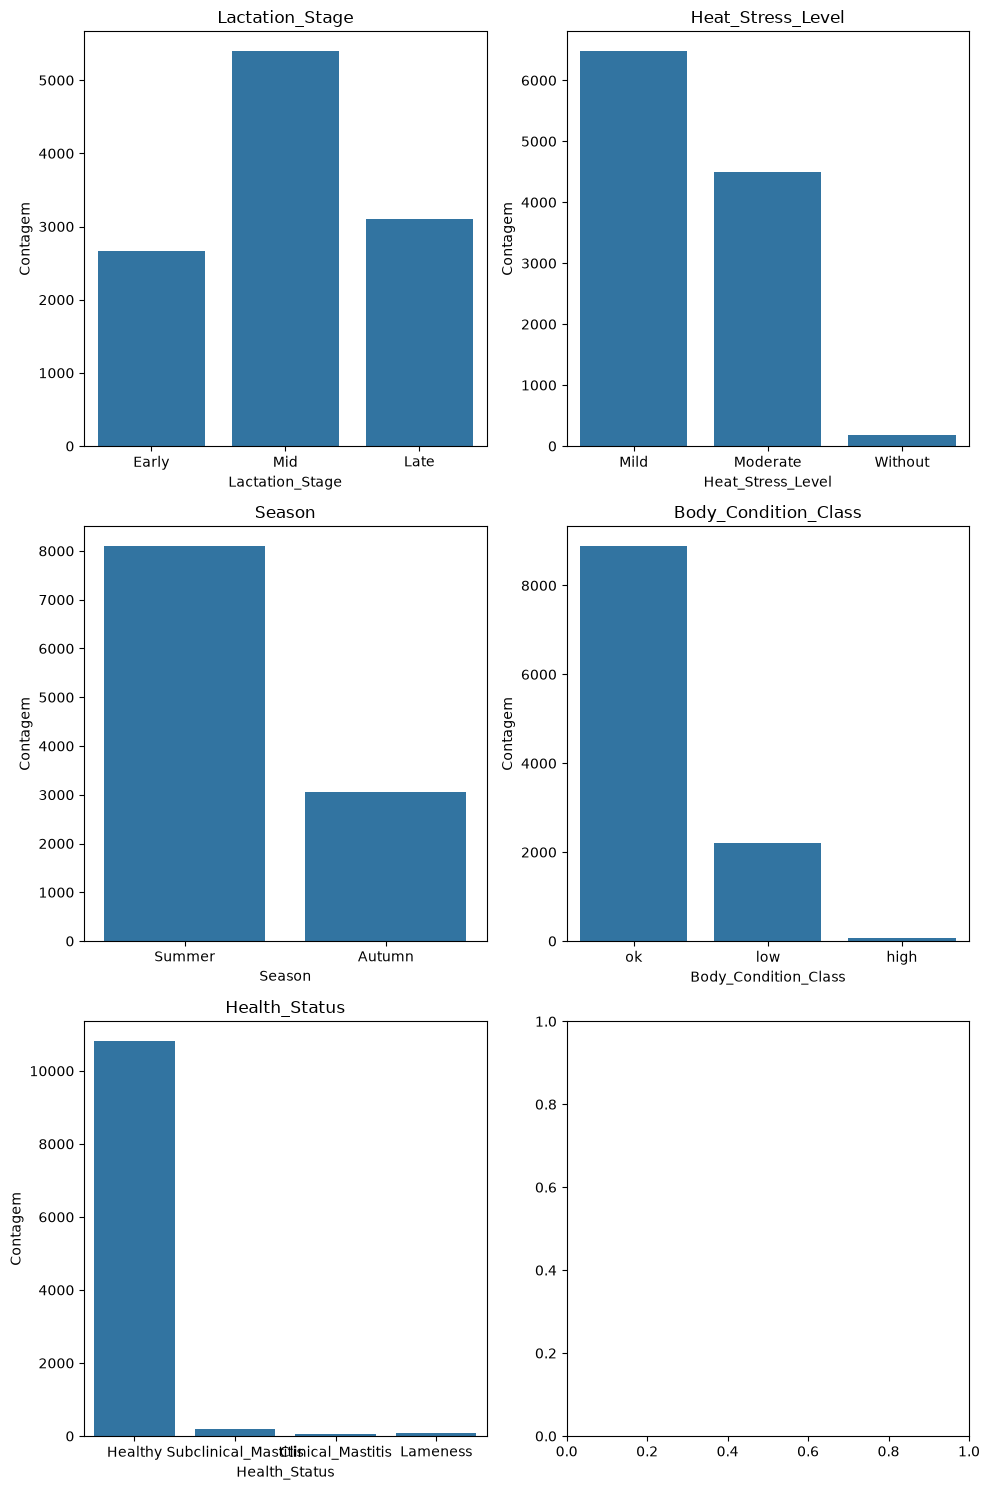

In [260]:
columns = ['Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status']

fig, axes = plt.subplots(3, 2, figsize = (10, 15))

for ax, columns in zip(axes.flat, columns):
    sns.countplot(data = cat_atributos, x = columns, ax = ax)
    ax.set_title(columns)
    ax.set_xlabel(columns)
    ax.set_ylabel('Contagem')

plt.tight_layout()
plt.show()

### Análise Bivariada

<Axes: xlabel='Lactation_Stage', ylabel='Media_Leite'>

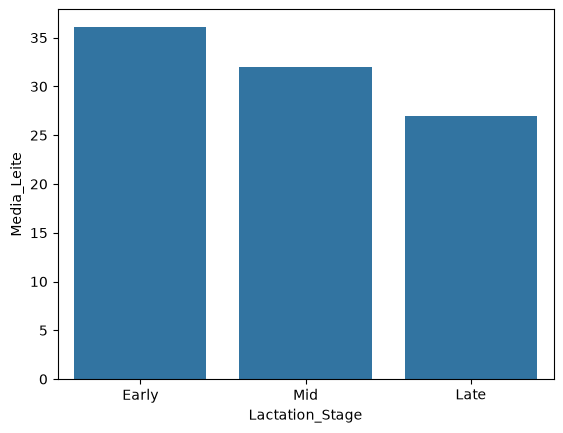

In [261]:
# 1. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio

aux = df2.groupby('Lactation_Stage')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Lactation_Stage', y='Media_Leite')


<Axes: xlabel='Age_Months', ylabel='Media_Leite'>

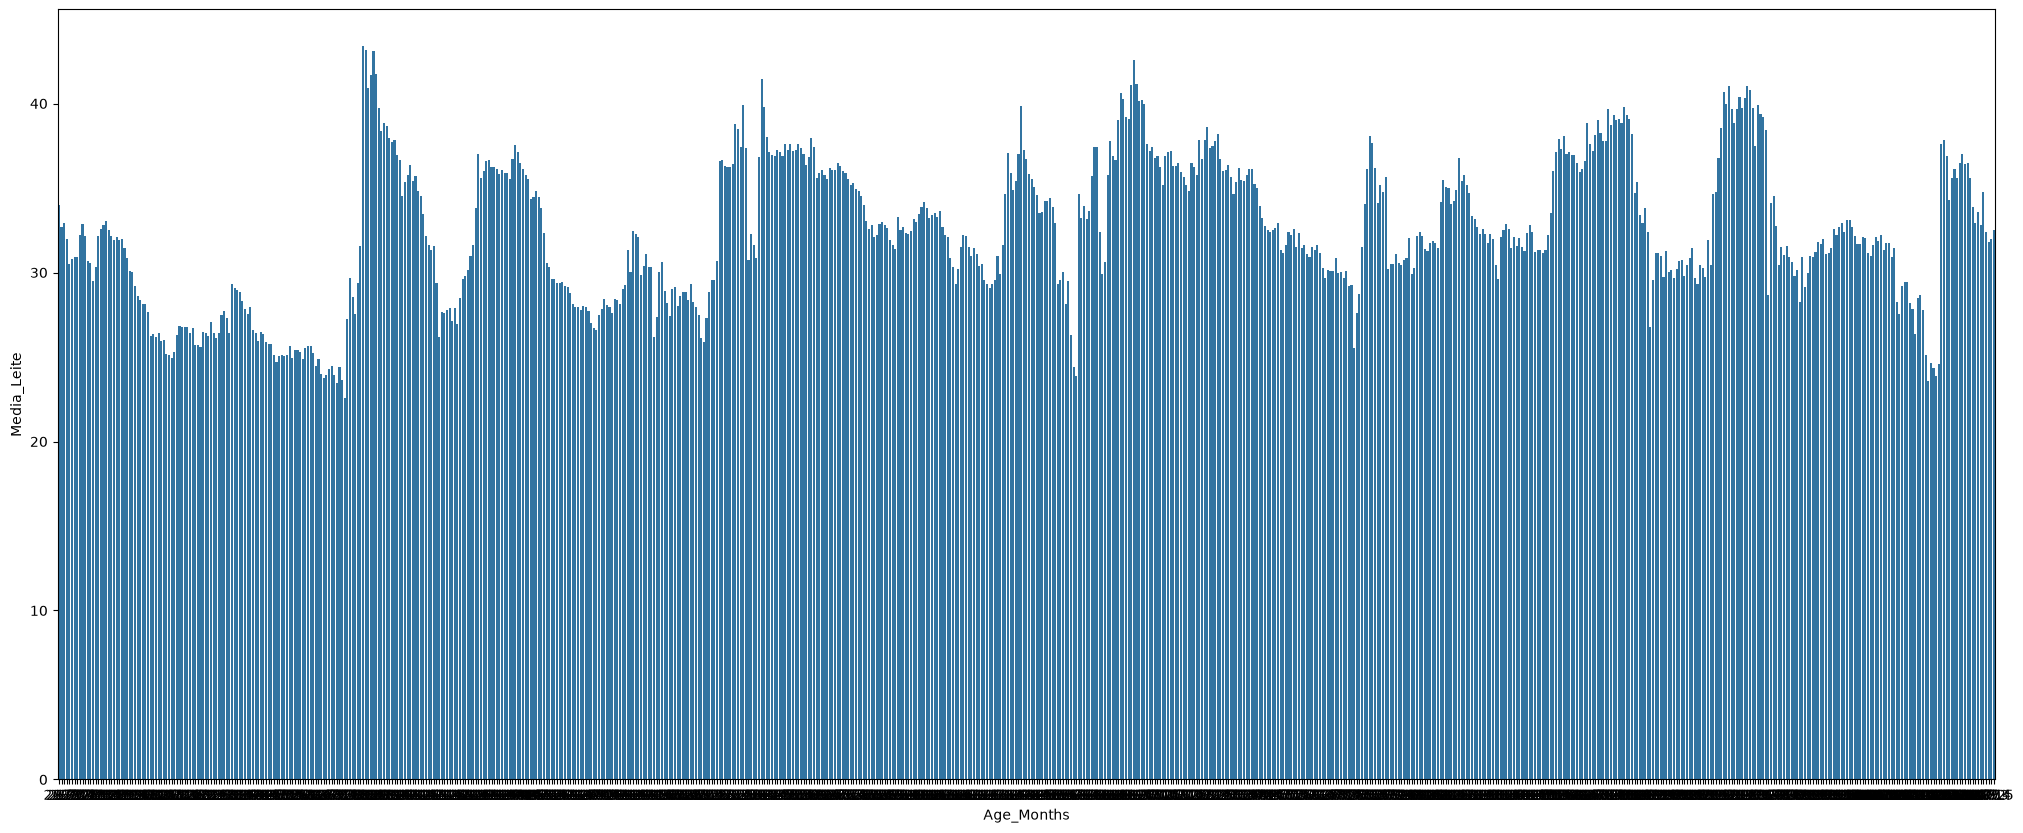

In [262]:
# 2. Vacas com idade mediana produz mais leite que as demais faixas de idade

aux = df2.groupby('Age_Months')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(25, 10))
sns.barplot(data=aux, x='Age_Months', y='Media_Leite')

<Axes: xlabel='Weight_kg', ylabel='Media_Leite'>

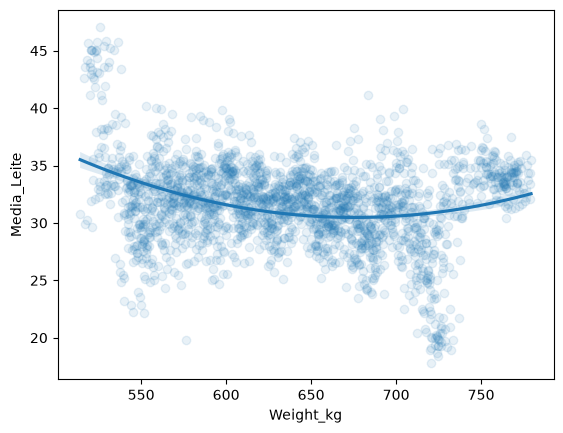

In [263]:
# 3. Vacas mais pesadas tendem a produzir mais leite

aux = df2.groupby('Weight_kg')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.regplot(data=aux, x='Weight_kg', y='Media_Leite', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Parity', ylabel='Media_Leite'>

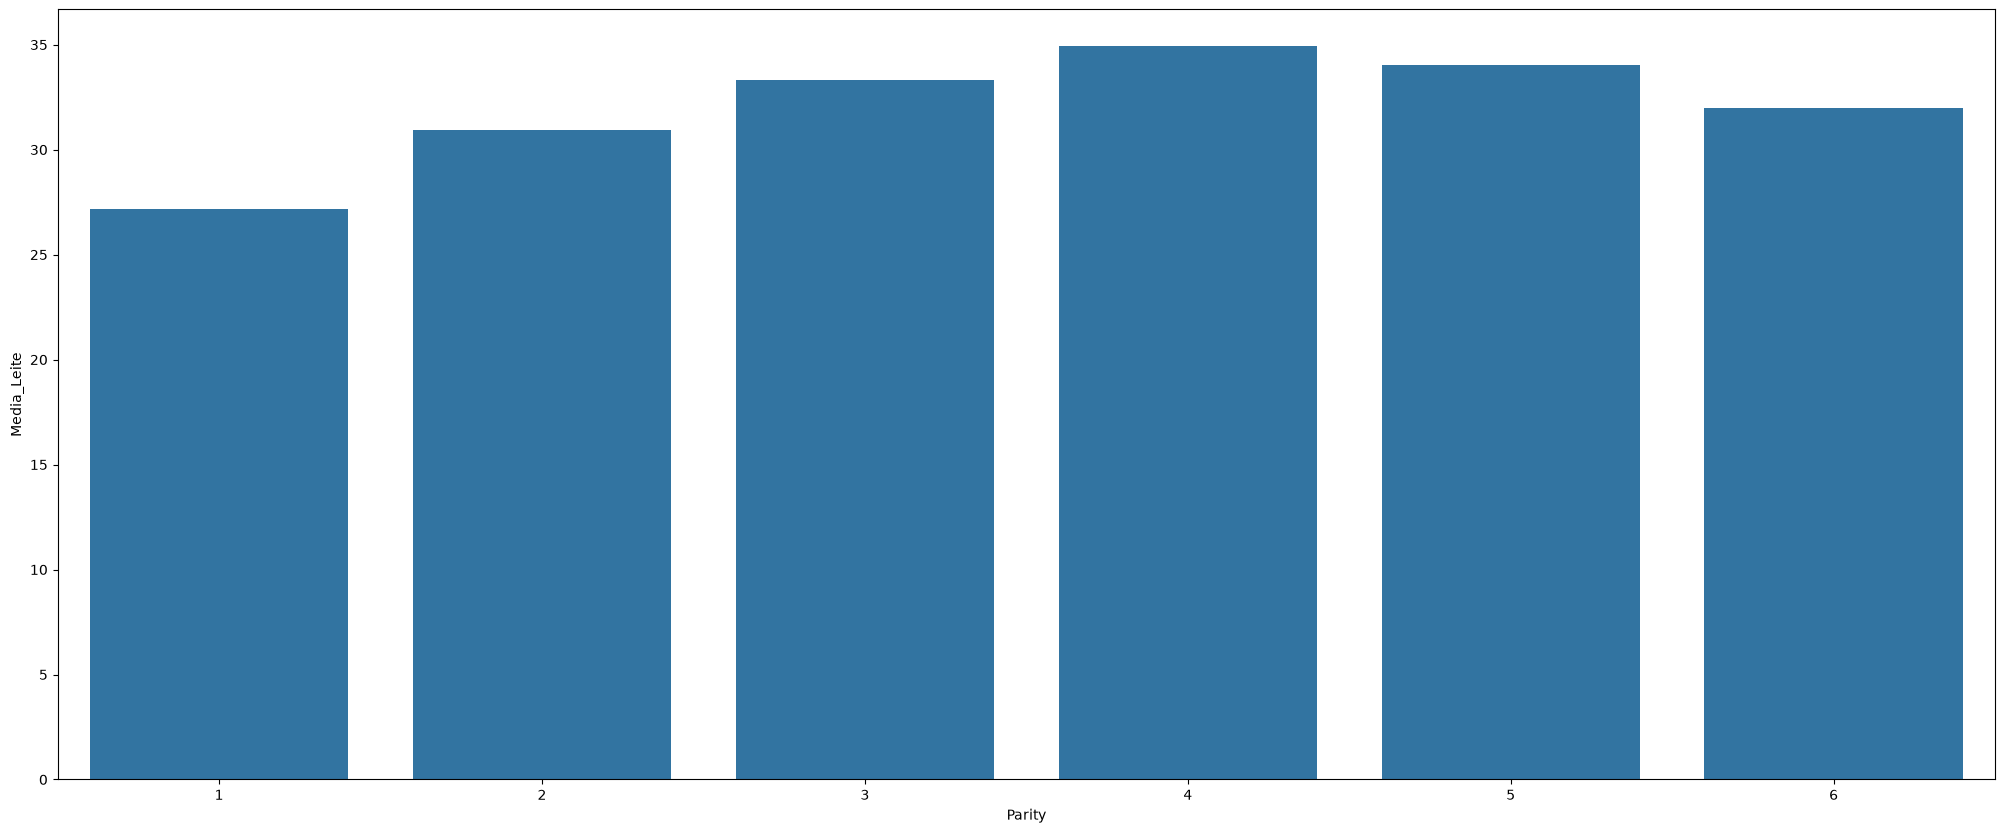

In [264]:
# 4. Vacas com número de partos mediano produz mais leite que as demais faixas de numero de partos

aux = df2.groupby('Parity')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(25, 10))
sns.barplot(data=aux, x='Parity', y='Media_Leite')


<Axes: xlabel='Water_Intake_L', ylabel='Media_Leite'>

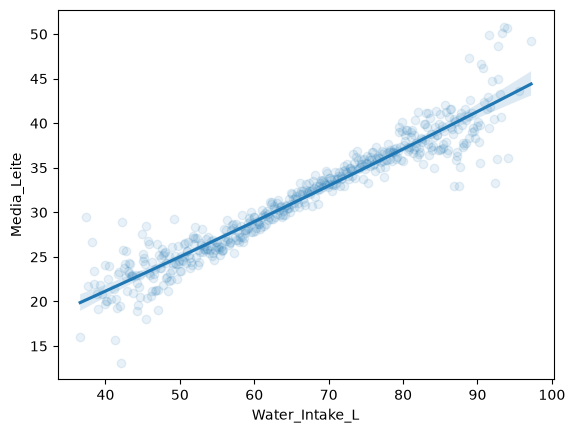

In [265]:
# 5. Vacas que ingerem mais águas produzem mais litros leite diários

aux = df2.groupby('Water_Intake_L')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.regplot(data=aux, x='Water_Intake_L', y='Media_Leite', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Walking_Distance_km', ylabel='Media_Leite'>

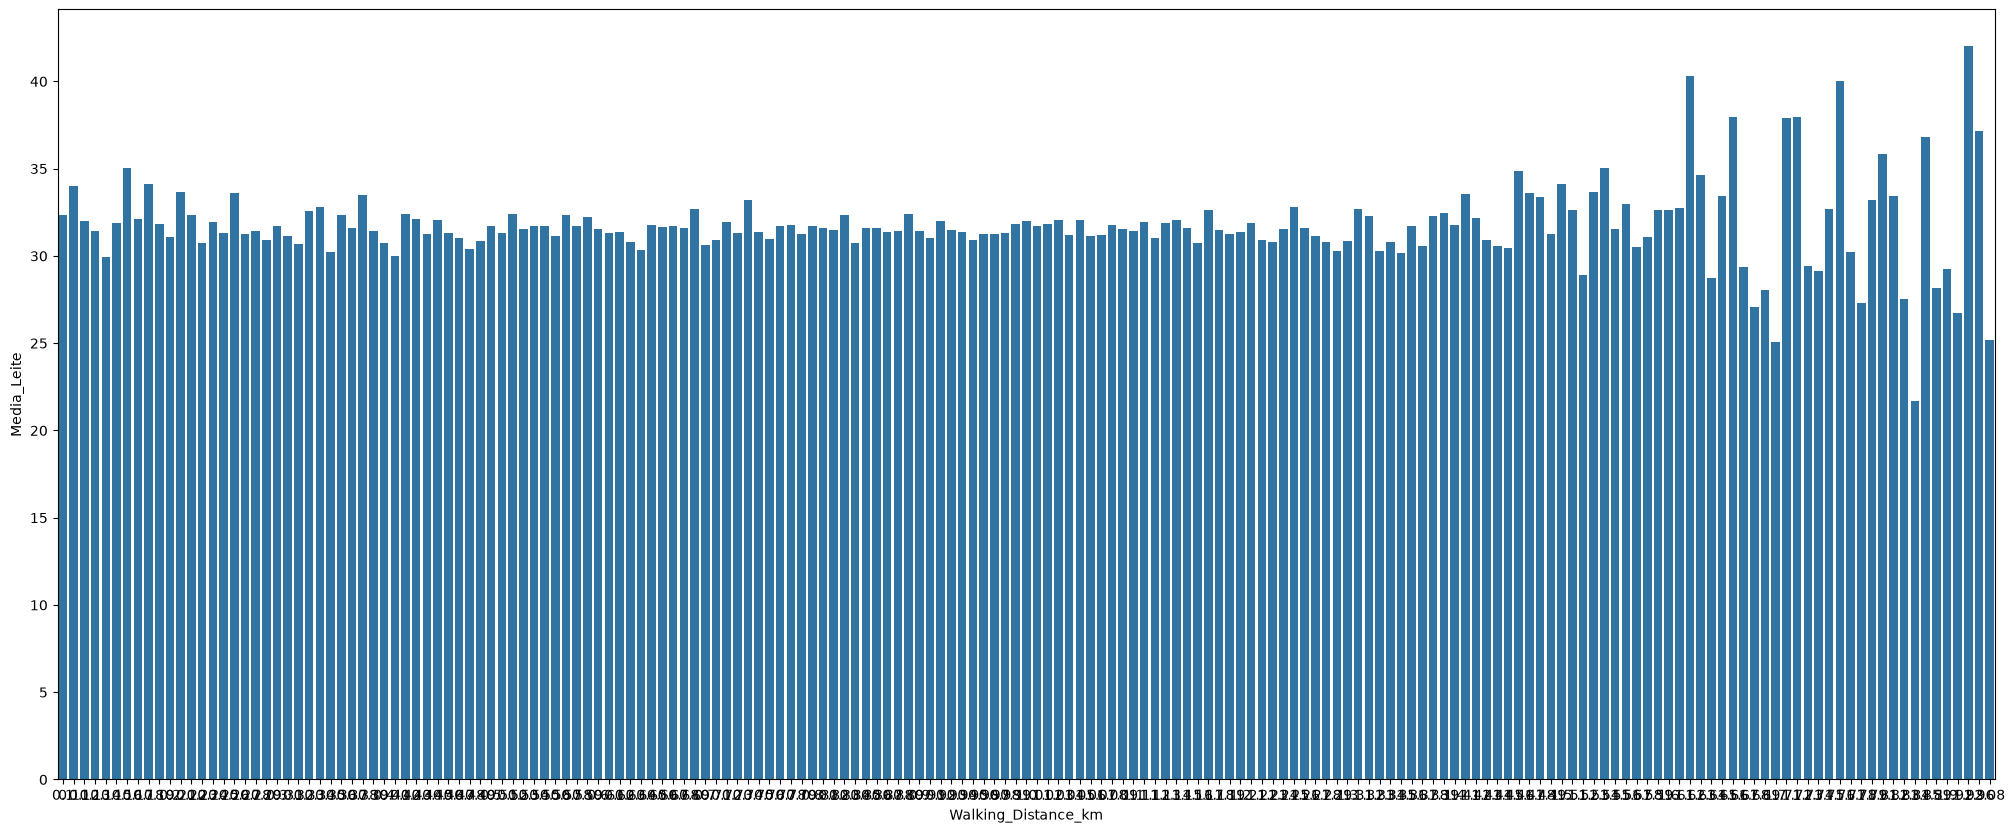

In [266]:
# 6. Vacas que andam mais, produzem menos litros de leite diários

aux = df2.groupby('Walking_Distance_km')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(25, 10))
sns.barplot(data=aux, x='Walking_Distance_km', y='Media_Leite')

<Axes: xlabel='Resting_Hours', ylabel='Media_Leite'>

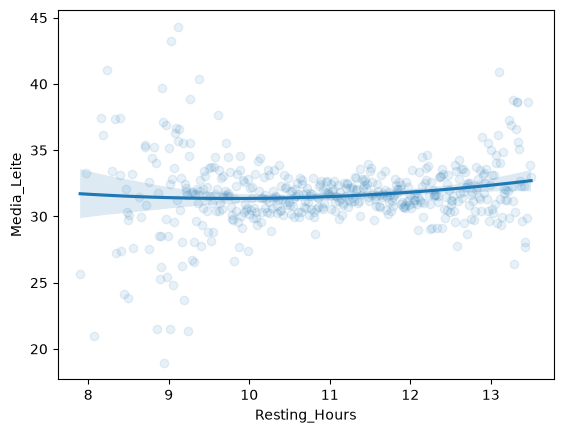

In [267]:
# 7. Vacas que descansam mais tem mais produtividade litros de leite diários

aux = df2.groupby('Resting_Hours')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.regplot(data=aux, x='Resting_Hours', y='Media_Leite', order=2, scatter_kws={'alpha': 0.1})


Season
Summer    8100
Autumn    3060
Name: count, dtype: int64

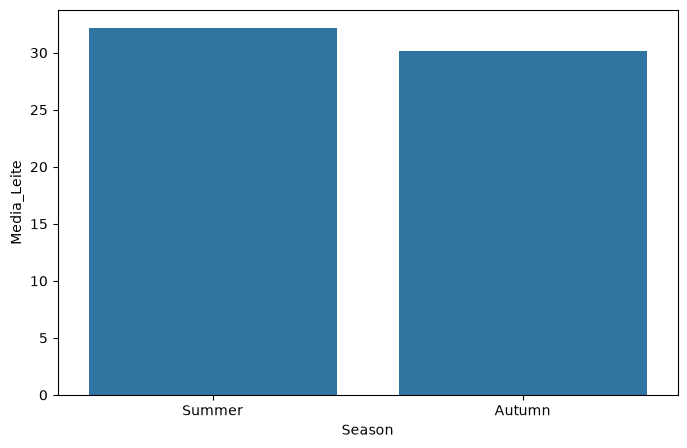

In [268]:
# 8. Vacas no outono produzem mais litros de leite diariamente

aux = df2.groupby('Season')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(8, 5))
sns.barplot(data=aux, x='Season', y='Media_Leite')

df2['Season'].value_counts()

<Axes: xlabel='Previous_Week_Avg_Yield', ylabel='Milk_Yield_L'>

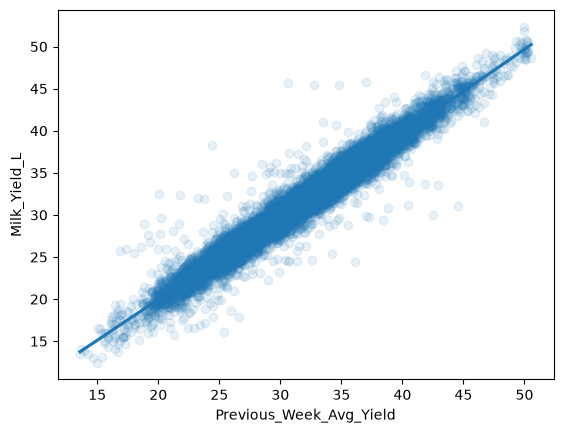

In [269]:
# 9. Na maior parte das vezes, vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite

sns.regplot(data=df2, x='Previous_Week_Avg_Yield', y='Milk_Yield_L', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Body_Condition_Score', ylabel='Media_Leite'>

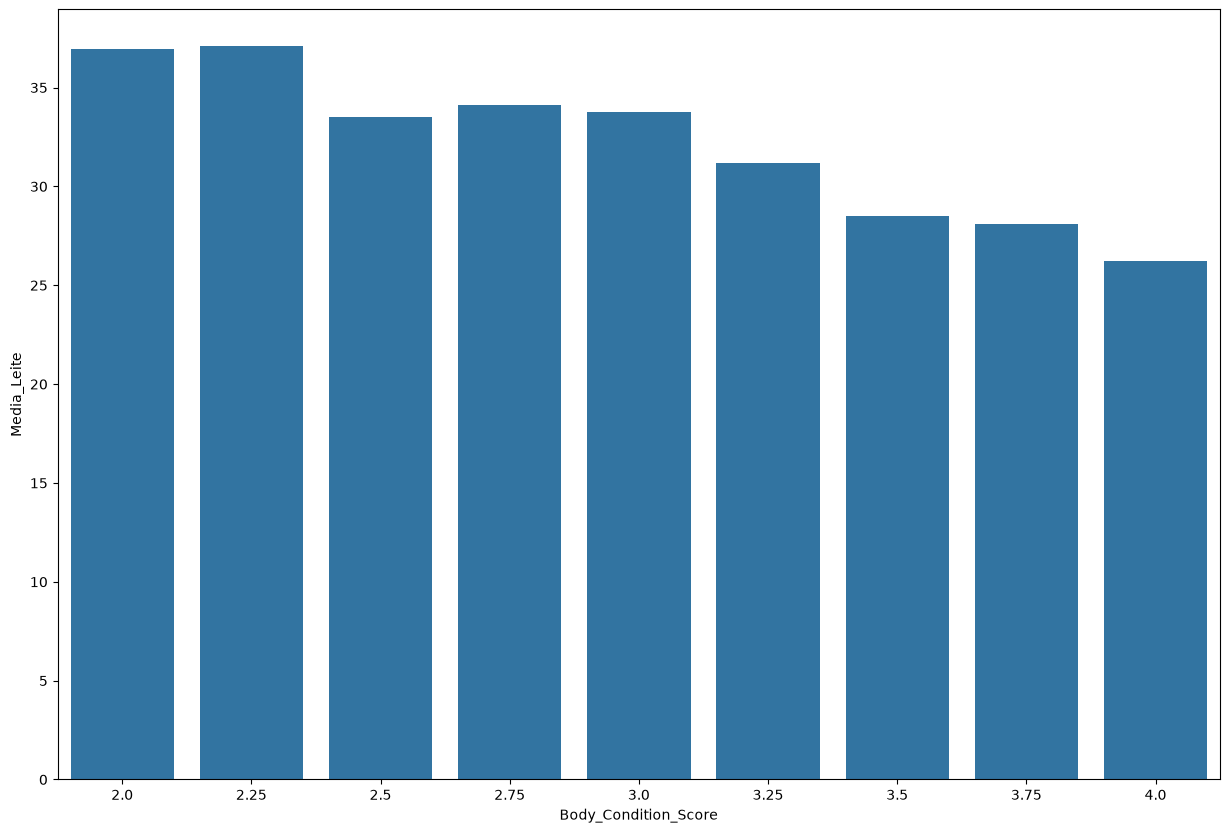

In [270]:
# 10. Vacas com score corporal 3 tendem a ter maior produtividade diária

aux = df2.groupby('Body_Condition_Score')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(15, 10))
sns.barplot(data=aux, x='Body_Condition_Score', y='Media_Leite')

<Axes: xlabel='Milking_Frequency_per_day', ylabel='Media_Leite'>

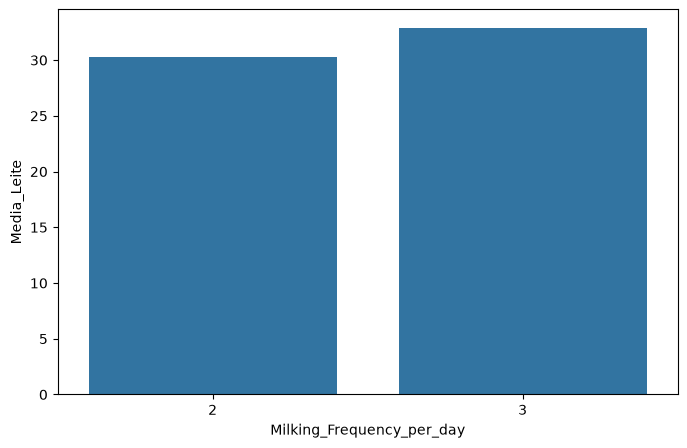

In [271]:
# 11. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária

aux = df2.groupby('Milking_Frequency_per_day')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(8, 5))
sns.barplot(data=aux, x='Milking_Frequency_per_day', y='Media_Leite')


<Axes: xlabel='Health_Status', ylabel='Media_Leite'>

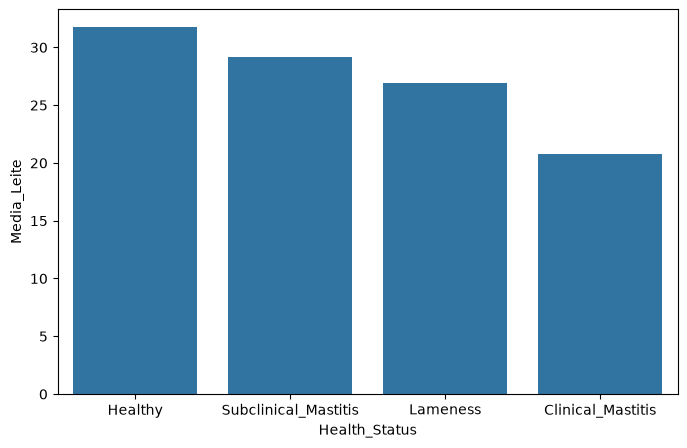

In [272]:
# 12. Vacas saudáveis tendem a produzir mais litros de leite 

aux = df2.groupby('Health_Status')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(8, 5))
sns.barplot(data=aux, x='Health_Status', y='Media_Leite')

<Axes: xlabel='Days_in_Milk', ylabel='Desvio'>

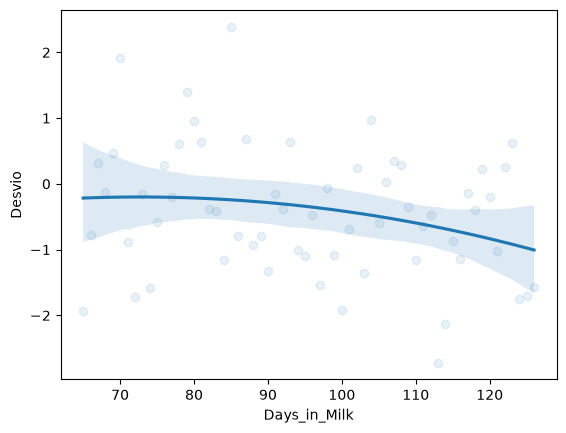

In [273]:
# 13. O desvio de produção aumenta negativamente com avanço do estágio da lactação

aux = df2.loc[df2['Cattle_ID'] == 'CATTLE_0001', :].reset_index()


sns.regplot(data=aux, x='Days_in_Milk', y='Desvio', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Days_in_Milk', ylabel='Milk_Yield_L'>

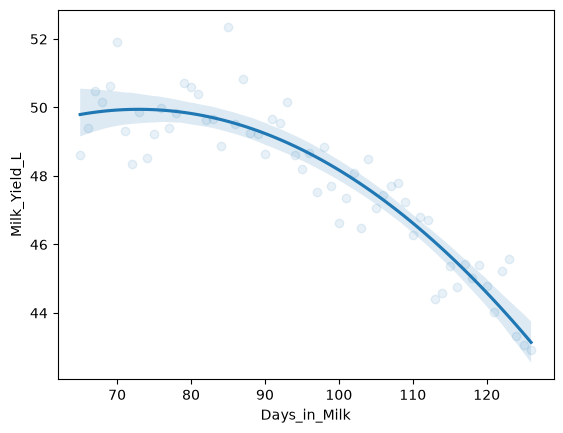

In [274]:
sns.regplot(data=aux, x='Days_in_Milk', y='Milk_Yield_L', order=2, scatter_kws={'alpha': 0.1})

In [275]:
df2.columns

Index(['Cattle_ID', 'Age_Months', 'Weight_kg', 'Parity', 'Lactation_Stage',
       'Days_in_Milk', 'Feed_Quantity_kg', 'Water_Intake_L',
       'Walking_Distance_km', 'Rumination_Time_hrs', 'Resting_Hours',
       'Ambient_Temperature_C', 'Humidity_percent',
       'Temperature_Humidity_Index', 'Heat_Stress_Level', 'Season',
       'Previous_Week_Avg_Yield', 'Body_Condition_Score',
       'Body_Condition_Class', 'Milking_Frequency_per_day', 'Health_Status',
       'Health_Event_Day', 'Date', 'Milk_Yield_L', 'Desvio',
       'Milk_Mean_15_Days_Ago', 'Milk_Yield_L_15_Days_from_now'],
      dtype='str')

1. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio: Falso. Cedo tem maior produtividade.
2. Vacas com idade mediana produzem mais litros de leite que as demais faixas de idade: Falso. Inconclusivo.
3. Vacas mais pesadas tendem a produzir mais leite: Falso. Inconclusivo.
4. Vacas com número de partos mediano produzem mais litros de leite que as demais faixas de numero de partos: Verdadeiro
5. Vacas que ingerem mais águas produzem mais litros leite diários: Verdadeiro
6. Vacas que andam mais, produzem menos litros de leite diários: Falso. Inconclusivo.
7. Vacas que descansam mais tem mais produtividade litros de leite diários: Falso. Inconclusivo.
8. Vacas no outono produzem mais litros de leite diariamente: Falso. No verão produz mais. 
9. Na maior parte das vezes, vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite. Verdadeiro
10. Vacas com score corporal 3 tendem a ter maior produtividade diária. Falso. Entre 2 e 2.5 tendem a ter maior produtividade.
11. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária: Verdadeiro.
12. Vacas saudáveis tendem a produzir mais litros de leite: Verdadeiro.
13. O desvio de produção aumenta negativamente com avanço do estágio da lactação: Verdadeiro.

In [276]:
resultados = pd.DataFrame({
    'Hipoteses': [i for i in range(1, 14)],
    'Avaliacao': ['F', 'F', 'F', 'V', 'V', 'F', 'F', 'F', 'V', 'F', 'V', 'V', 'V']
})

resultados

,Hipoteses,Avaliacao
0,1,F
1,2,F
2,3,F
3,4,V
4,5,V
5,6,F
6,7,F
7,8,F
8,9,V
9,10,F


### Análise Multivariada

#### Variáveis Numéricas

<Axes: >

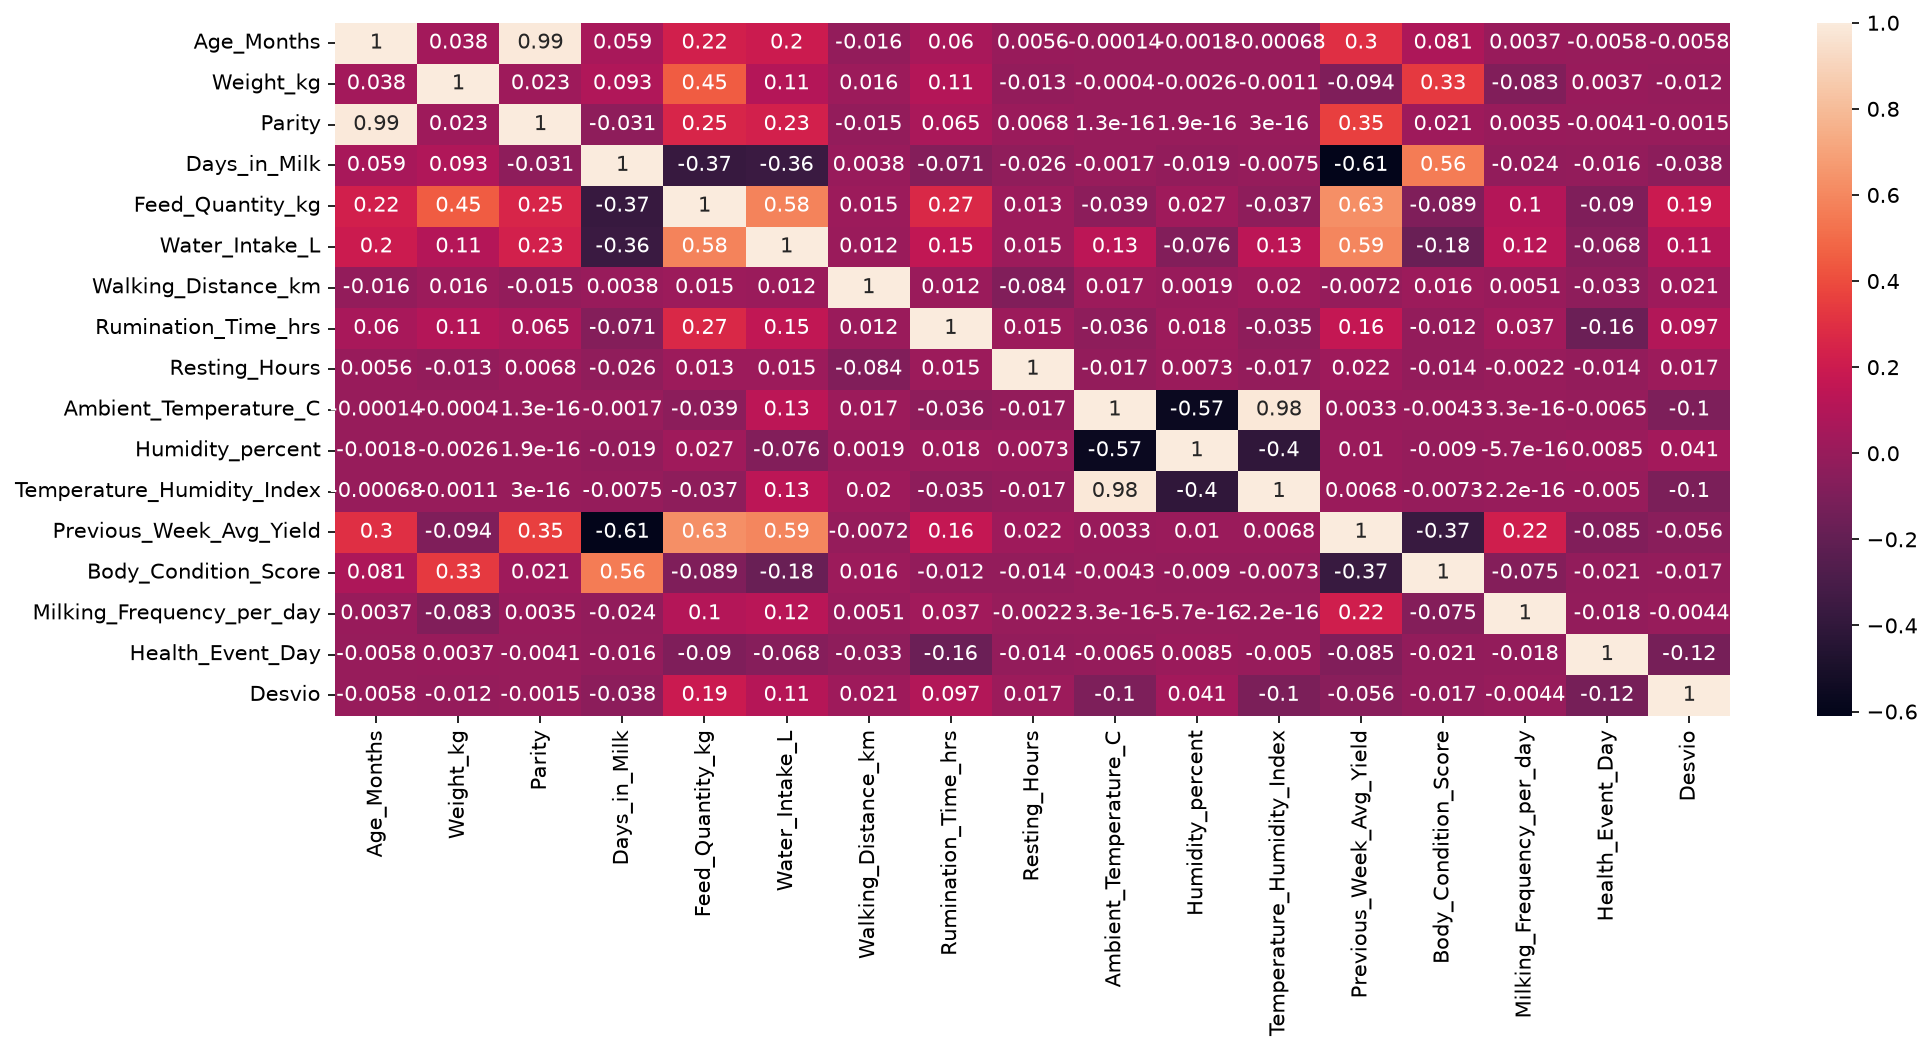

In [277]:
num_atributos_2 = num_atributos.drop(['Milk_Yield_L', 'Milk_Mean_15_Days_Ago', 'Milk_Yield_L_15_Days_from_now'], axis=1)

correlation_matrix = num_atributos_2.corr(method='pearson')

plt.figure(figsize=(15, 6), dpi=150)
sns.heatmap(correlation_matrix, annot=True)

#### Variáveis Categóricas

In [278]:

print(cat_atributos.columns)

cat_atributos

Index(['Cattle_ID', 'Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status'],
      dtype='str')


,Cattle_ID,Lactation_Stage,Heat_Stress_Level,Season,Body_Condition_Class,Health_Status
2700,CATTLE_0001,Early,Mild,Summer,ok,Healthy
2701,CATTLE_0002,Early,Mild,Summer,low,Healthy
2702,CATTLE_0003,Early,Mild,Summer,low,Healthy
2703,CATTLE_0004,Early,Mild,Summer,ok,Healthy
2704,CATTLE_0005,Mid,Mild,Summer,ok,Healthy
...,...,...,...,...,...,...
13855,CATTLE_0176,Mid,Mild,Autumn,ok,Healthy
13856,CATTLE_0177,Late,Mild,Autumn,high,Healthy
13857,CATTLE_0178,Late,Mild,Autumn,ok,Healthy
13858,CATTLE_0179,Late,Mild,Autumn,ok,Healthy


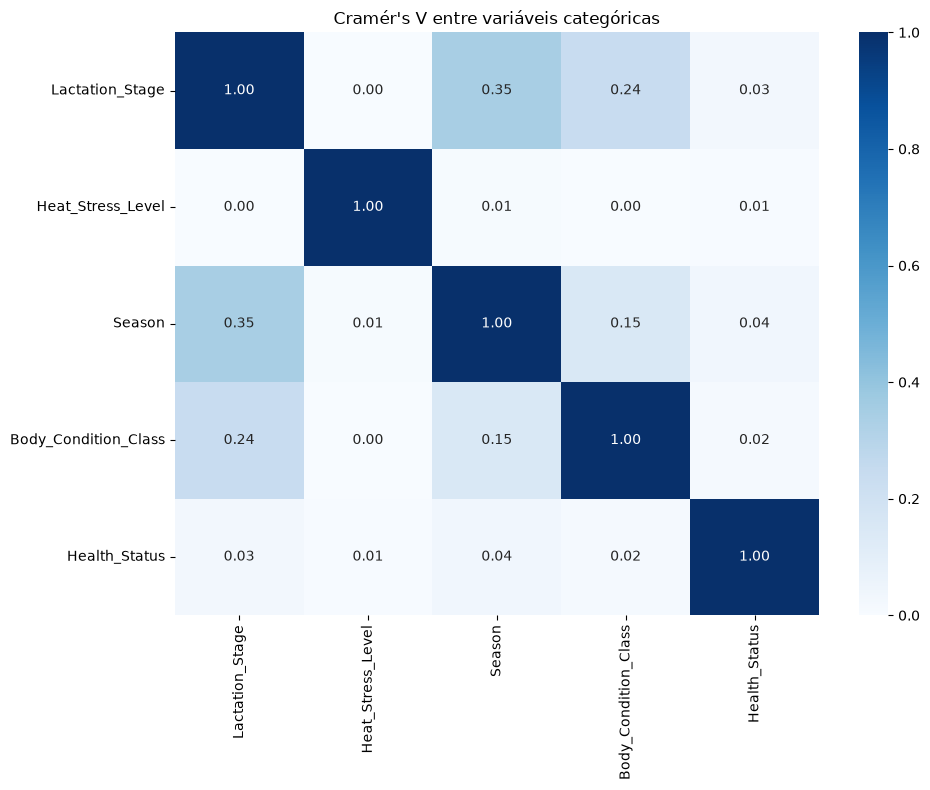

In [279]:
cat_cols = ['Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status']

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramer_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramer_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title("Cramér's V entre variáveis categóricas")
plt.tight_layout()
plt.show()

# Preparação de Dados

### Separação conjunto treino e teste

In [280]:
df2 = df2.drop(['Body_Condition_Class', 'Temperature_Humidity_Index', 'Age_Months', 'Cattle_ID'], axis=1)

In [281]:
df3 = df2.copy()

In [282]:
# Data de corte (últimos 15 dias para teste)

cutoff = df3['Date'].max() - pd.Timedelta(days=15)

train = df3[df3['Date'] <= cutoff]
test = df3[df3['Date'] > cutoff]

x_train_raw = train.drop(columns=['Milk_Yield_L_15_Days_from_now'])
y_train_raw = train['Milk_Yield_L_15_Days_from_now']

x_test_raw = test.drop(columns=['Milk_Yield_L_15_Days_from_now'])
y_test_raw = test['Milk_Yield_L_15_Days_from_now']

### Enconding

In [283]:
#Ordinal Enconding x_train
x_train_raw['Season'] = x_train_raw['Season'].apply(lambda x: 0 if x == 'Summer' else 1)

x_train_raw['Lactation_Stage'] = x_train_raw['Lactation_Stage'].apply(lambda x: 0 if x == 'Early' else (1 if x == 'Mid' else 2))

x_train_raw['Heat_Stress_Level'] = x_train_raw['Heat_Stress_Level'].apply(lambda x: 0 if x == 'Without' else (1 if x == 'Mild' else 2))

In [284]:
#Ordinal Enconding x_test_raw
x_test_raw['Season'] = x_test_raw['Season'].apply(lambda x: 0 if x == 'Summer' else 1)

x_test_raw['Lactation_Stage'] = x_test_raw['Lactation_Stage'].apply(lambda x: 0 if x == 'Early' else (1 if x == 'Mid' else 2))

x_test_raw['Heat_Stress_Level'] = x_test_raw['Heat_Stress_Level'].apply(lambda x: 0 if x == 'Without' else (1 if x == 'Mild' else 2))

In [285]:
#Hot_One_Enconding_-_Health_Status_-_x_train
x_train_encode = pd.get_dummies(x_train_raw, prefix=['Health_Status'], columns=['Health_Status'], dtype = int)
x_train_encode.head().T


,2700,2701,2702,2703,2704
Weight_kg,646.2,634.7,631.1,565.1,671.6
Parity,3,5,3,5,3
Lactation_Stage,0,0,0,0,1
Days_in_Milk,65,70,35,96,152
Feed_Quantity_kg,24.46,23.66,21.79,20.32,21.97
Water_Intake_L,86.5,69.6,75.0,69.8,59.5
Walking_Distance_km,0.69,0.44,1.25,0.76,0.9
Rumination_Time_hrs,7.99,7.1,7.38,7.68,7.28
Resting_Hours,10.33,11.71,11.69,11.86,9.91
Ambient_Temperature_C,24.0,24.0,24.0,24.0,24.0


In [286]:
#Hot One Enconding - Health_Status - x_test
x_test_encode = pd.get_dummies(x_test_raw, prefix=['Health_Status'], columns=['Health_Status'], dtype = int)
x_test_encode.head().T

,11160,11161,11162,11163,11164
Weight_kg,649.6,640.2,638.8,580.4,668.9
Parity,3,5,3,5,3
Lactation_Stage,1,1,0,1,1
Days_in_Milk,112,117,82,143,199
Feed_Quantity_kg,25.59,22.41,21.7,19.57,20.8
Water_Intake_L,85.2,69.3,80.1,66.4,74.0
Walking_Distance_km,1.41,0.68,1.21,0.3,0.77
Rumination_Time_hrs,8.11,7.62,7.41,7.68,6.94
Resting_Hours,10.03,11.5,11.07,11.63,10.86
Ambient_Temperature_C,26.3,26.3,26.3,26.3,26.3


In [287]:
#transformando Date: transformação de natureza x_train_encode

#criando a coluna mes 
x_train_encode['month'] = x_train_encode['Date'].dt.month 
#criando a coluna ano 
x_train_encode['day'] = x_train_encode['Date'].dt.day

In [288]:
#transformando Date: transformação de natureza x_test_encode

#criando a coluna mes 
x_test_encode['month'] = x_test_encode['Date'].dt.month 
#criando a coluna ano 
x_test_encode['day'] = x_test_encode['Date'].dt.day

In [289]:
# dia 
x_train_encode['day_sin'] = x_train_encode['day'].apply( lambda x: np.sin(x * (2 * np.pi/30))) 

x_train_encode['day_cos'] = x_train_encode['day'].apply( lambda x: np.cos(x * (2 * np.pi/30)) ) 

x_test_encode['day_sin'] = x_test_encode['day'].apply( lambda x: np.sin(x * (2 * np.pi/30))) 

x_test_encode['day_cos'] = x_test_encode['day'].apply( lambda x: np.cos(x * (2 * np.pi/30)))

In [290]:
# mÊs
x_train_encode['month_sin'] = x_train_encode['month'].apply( lambda x: np.sin(x * (2 * np.pi/12))) 

x_train_encode['month_cos'] = x_train_encode['month'].apply( lambda x: np.cos(x * (2 * np.pi/12)) ) 

x_test_encode['month_sin'] = x_test_encode['month'].apply( lambda x: np.sin(x * (2 * np.pi/12))) 

x_test_encode['month_cos'] = x_test_encode['month'].apply( lambda x: np.cos(x * (2 * np.pi/12)))

In [291]:
x_train_encode = x_train_encode.drop(['Date', 'month', 'day'], axis=1)
x_test_encode = x_test_encode.drop(['Date', 'month', 'day'], axis=1)

In [292]:
x_test_encode.head(10).T

,11160,11161,11162,11163,11164,11165,11166,11167,11168,11169
Weight_kg,6.496000e+02,6.402000e+02,6.388000e+02,5.804000e+02,6.689000e+02,5.898000e+02,6.036000e+02,6.641000e+02,6.463000e+02,5.859000e+02
Parity,3.000000e+00,5.000000e+00,3.000000e+00,5.000000e+00,3.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,3.000000e+00,1.000000e+00
Lactation_Stage,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
Days_in_Milk,1.120000e+02,1.170000e+02,8.200000e+01,1.430000e+02,1.990000e+02,9.700000e+01,1.480000e+02,1.700000e+02,1.540000e+02,2.620000e+02
Feed_Quantity_kg,2.559000e+01,2.241000e+01,2.170000e+01,1.957000e+01,2.080000e+01,2.093000e+01,2.313000e+01,2.266000e+01,2.172000e+01,1.625000e+01
Water_Intake_L,8.520000e+01,6.930000e+01,8.010000e+01,6.640000e+01,7.400000e+01,7.000000e+01,6.000000e+01,6.920000e+01,7.470000e+01,5.020000e+01
Walking_Distance_km,1.410000e+00,6.800000e-01,1.210000e+00,3.000000e-01,7.700000e-01,1.280000e+00,1.030000e+00,1.240000e+00,7.100000e-01,5.300000e-01
Rumination_Time_hrs,8.110000e+00,7.620000e+00,7.410000e+00,7.680000e+00,6.940000e+00,7.220000e+00,7.650000e+00,7.670000e+00,6.910000e+00,6.880000e+00
Resting_Hours,1.003000e+01,1.150000e+01,1.107000e+01,1.163000e+01,1.086000e+01,1.139000e+01,1.169000e+01,1.108000e+01,1.250000e+01,1.159000e+01
Ambient_Temperature_C,2.630000e+01,2.630000e+01,2.630000e+01,2.630000e+01,2.630000e+01,2.630000e+01,2.630000e+01,2.630000e+01,2.630000e+01,2.630000e+01


### Rescaling

Trazer a escala de número para médida 0, com desvio padrão reduzido

- StandardScaler -> quando minha skew está cotrolada, entre -0.5 e 0.5
- MinMaxScaler -> quando minha skew estiver controlada e o df não tiver outlier
- RobustScaler -> quando a skew não está muito controlada e o df possuir outlier

In [293]:
x_train_encode.columns

Index(['Weight_kg', 'Parity', 'Lactation_Stage', 'Days_in_Milk',
       'Feed_Quantity_kg', 'Water_Intake_L', 'Walking_Distance_km',
       'Rumination_Time_hrs', 'Resting_Hours', 'Ambient_Temperature_C',
       'Humidity_percent', 'Heat_Stress_Level', 'Season',
       'Previous_Week_Avg_Yield', 'Body_Condition_Score',
       'Milking_Frequency_per_day', 'Health_Event_Day', 'Milk_Yield_L',
       'Desvio', 'Milk_Mean_15_Days_Ago', 'Health_Status_Clinical_Mastitis',
       'Health_Status_Healthy', 'Health_Status_Lameness',
       'Health_Status_Subclinical_Mastitis', 'day_sin', 'day_cos', 'month_sin',
       'month_cos'],
      dtype='str')

In [294]:
columns_scaler = ['Weight_kg', 'Parity', 'Lactation_Stage', 'Days_in_Milk',
       'Feed_Quantity_kg', 'Water_Intake_L', 'Walking_Distance_km',
       'Rumination_Time_hrs', 'Resting_Hours', 'Ambient_Temperature_C',
       'Humidity_percent', 'Heat_Stress_Level', 'Season',
       'Previous_Week_Avg_Yield', 'Body_Condition_Score',
       'Milking_Frequency_per_day', 'Health_Event_Day', 'Milk_Yield_L',
       'Desvio', 'Milk_Mean_15_Days_Ago']

ss = StandardScaler()

for i in columns_scaler:
    x_train_encode[i] = ss.fit_transform(x_train_encode[[i]].values)

    x_test_encode[i] = ss.transform(x_test_encode[[i]].values)

x_train_encode.head().T

,2700,2701,2702,2703,2704
Weight_kg,0.409974,0.160789,0.082783,-1.347323,0.960348
Parity,0.031603,1.295742,0.031603,1.295742,0.031603
Lactation_Stage,-1.320005,-1.320005,-1.320005,-1.320005,0.067230
Days_in_Milk,-1.384060,-1.300526,-1.885262,-0.866151,0.069426
Feed_Quantity_kg,1.456637,1.059889,0.132490,-0.596535,0.221758
Water_Intake_L,2.286486,0.346408,0.966314,0.369367,-0.813047
Walking_Distance_km,-0.499608,-1.291566,1.274379,-0.277859,0.165637
Rumination_Time_hrs,0.756408,-1.236153,-0.609280,0.062370,-0.833163
Resting_Hours,-1.015668,0.613400,0.589790,0.790472,-1.511472
Ambient_Temperature_C,0.329075,0.329075,0.329075,0.329075,0.329075


# Feature Selection